# Continual Learning of ALRNN in the Multitask Setting

In [3]:
# ==========================================
# 1. Imports and Setup
# ==========================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from typing import List

# Import your modules
from rnn_model import PLRNN, compute_accuracies
from MAR import regularization_loss
from Dataset import MultiTaskDataset, CognitiveTask, DelayedResponse, ReactionTime, collate_fn, ContinuousMultitaskDataset
from analysis_functions import bitcode_distribution, plot_bitcode_distribution

# Set Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

Running on: cpu


In [4]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    # 1. Base Python randomness
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. NumPy randomness
    np.random.seed(seed)
    
    # 3. PyTorch randomness (CPU and GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    
    # 4. Force CuDNN to be deterministic
    # This ensures that even the low-level GPU math is identical
    # Note: This can slightly slow down training
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f">>> Seed set to: {seed}")

# Usage: Call this at the very top of your script
set_seed(42)

>>> Seed set to: 42


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_multitask_results(results, model_name, num_tasks):
    """
    Plots accuracy history for an arbitrary number of tasks.
    
    Args:
        results (dict): Dictionary containing experiment results (keys like 'Vanilla 1', 'EWC 1').
                        Values must be dicts with keys 'acc_task1', 'acc_task2', etc.
        model_name (str): Name of the model for the title.
        num_tasks (int): Number of tasks to plot (creates one subplot per task).
    """
    
    # 1. Setup Layout
    # Create 1 subplot per task
    fig, axes = plt.subplots(1, num_tasks, figsize=(6 * num_tasks, 6))
    if num_tasks == 1: axes = [axes] # Handle edge case of single task
    
    fig.suptitle(f"Results for: {model_name} (Solid=EWC, Dashed=Vanilla)", fontsize=16)

    # 2. Setup Colors
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    # 3. Get Time Axis & Switch Points
    first_key = list(results.keys())[0]
    # Check key existence to be safe
    if 'acc_task1' not in results[first_key]:
        print("Error: Results dictionary missing 'acc_task1'. Check your data keys.")
        return

    epochs_total = len(results[first_key]['acc_task1'])
    x_axis = range(epochs_total)
    
    # Calculate switch points (assuming equal epochs per task)
    switch_interval = epochs_total // num_tasks
    switch_points = [i * switch_interval for i in range(1, num_tasks)]

    # 4. Configure Axes
    for i, ax in enumerate(axes):
        task_num = i + 1
        ax.set_title(f"Task {task_num} Accuracy")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Accuracy")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05) # Lock accuracy to 0-1 range
        
        # Draw Switch Lines
        for sp in switch_points:
            ax.axvline(sp, color='k', linestyle=':', alpha=0.5)
            
        # Highlight the "Active Phase" for this task
        # (Optional: shades the background where this task was being trained)
        start = (task_num - 1) * switch_interval
        end = task_num * switch_interval
        ax.axvspan(start, end, color='gray', alpha=0.05, label='Active Training')

    # 5. Plot Data
    for name, res in results.items():
        # A. Extract seed index for consistent coloring
        # Finds the first number in the string (e.g. "Vanilla 1" -> 1)
        try:
            seed_idx = int(''.join(filter(str.isdigit, name))) - 1
        except ValueError:
            seed_idx = 0 # Fallback if no number found
            
        color = colors[seed_idx % len(colors)]
        
        # B. Set Style (Vanilla vs EWC)
        if "Vanilla" in name:
            style = '--'
            alpha = 0.5
            width = 1.5
            zorder = 1
        else:
            style = '-'
            alpha = 0.9
            width = 2.5
            zorder = 2
            
        # C. Loop through subplots/tasks
        for i, ax in enumerate(axes):
            task_key = f'acc_task{i+1}'
            
            if task_key in res:
                # Label only on the first subplot to keep legend clean
                lbl = name if i == 0 else ""
                
                ax.plot(x_axis, res[task_key], 
                        label=lbl,
                        linestyle=style, 
                        linewidth=width, 
                        color=color, 
                        alpha=alpha,
                        zorder=zorder)

    # 6. Final Polish
    # Add legend only to the first plot
    axes[0].legend(loc='lower left', fontsize='x-small', ncol=2)
    
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# plot_multitask_results(results, "PLRNN (AL)", num_tasks=2)

## 2 Tasks

Input Dimension: 11
Initializing Fully Nonlinear PLRNN (M=100, L=4)...

=== Phase 1/2: Training on DelayedResponse (pro) ===
  Epoch 5/20 | Loss: 0.8750 | T0*: 100% T1: 4% 
  Epoch 10/20 | Loss: 0.7152 | T0*: 100% T1: 3% 
  Epoch 15/20 | Loss: 0.5989 | T0*: 100% T1: 6% 
  Epoch 20/20 | Loss: 0.4994 | T0*: 100% T1: 3% 

=== Phase 2/2: Training on DelayedResponse (anti) ===
  Epoch 5/20 | Loss: 0.4346 | T0: 6% T1*: 100% 
  Epoch 10/20 | Loss: 0.3491 | T0: 3% T1*: 100% 
  Epoch 15/20 | Loss: 0.2839 | T0: 4% T1*: 100% 
  Epoch 20/20 | Loss: 0.2299 | T0: 4% T1*: 100% 


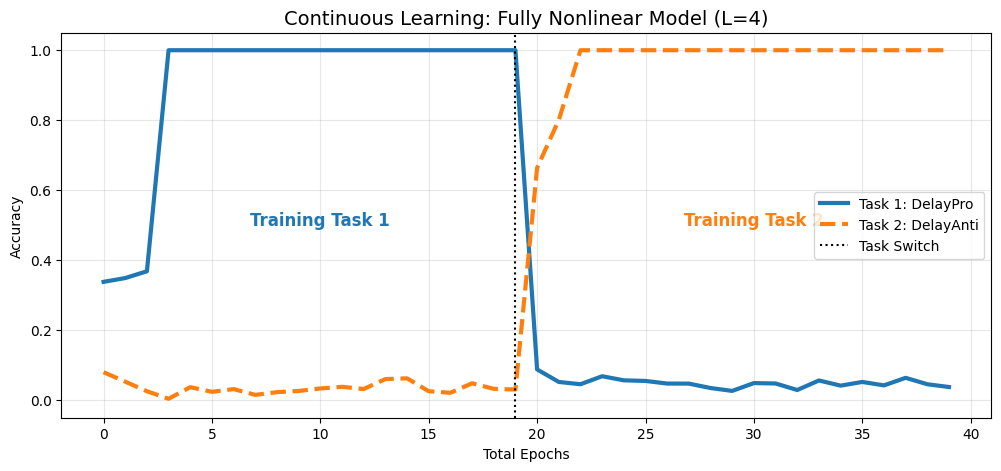


=== Final Results ===
Final Accuracy on Task 1 (Old): 3.77%
Final Accuracy on Task 2 (New): 100.00%
>> OBSERVATION: Catastrophic Forgetting occurred.


In [ ]:
# ==========================================
# 2. Define the New Continuous Dataset Class
# ==========================================
class ContinuousMultitaskDataset(MultiTaskDataset):
    """
    Dataset for Continuous Learning:
    - Generates trials from a SINGLE 'active' task at a time.
    - Preserves the GLOBAL input dimension (Task ID one-hot vector matches total tasks).
    """
    def __init__(self, tasks: List[CognitiveTask], n_trials: int = 1000):
        super().__init__(tasks, n_trials)
        self.active_task_idx = 0  # Default to the first task
        
    def set_active_task(self, task_idx: int):
        """Updates the dataset to generate trials only for the specified task index."""
        if 0 <= task_idx < len(self.tasks):
            self.active_task_idx = task_idx
        else:
            raise ValueError(f"Invalid task index {task_idx}. Max is {len(self.tasks)-1}")

    def __getitem__(self, idx):
        # 1. Select the CURRENTLY ACTIVE task
        task_idx = self.active_task_idx
        task = self.tasks[task_idx]
        
        # 2. Generate trial (automatically padded via task.__call__)
        inputs, targets, mask = task()
        
        # 3. Add task identity (Global One-Hot Encoding)
        # CRITICAL: Vector size is based on ALL tasks, ensuring input dimension consistency
        task_id = torch.zeros(inputs.shape[0], len(self.tasks))
        task_id[:, task_idx] = 1
        
        inputs = torch.cat([inputs, task_id], dim=1)
        
        return inputs, targets, mask, task_idx

# ==========================================
# 3. Define the Clean Training Function
# ==========================================
def train_continuous(model, tasks, optimizer, device, test_loader_all,
                           tau=0.01, M_reg=10, 
                           epochs_per_task=20, trials_per_epoch=1000):
    
    # Initialize the Continuous Dataset with ALL tasks
    train_dataset = ContinuousMultitaskDataset(tasks, n_trials=trials_per_epoch)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    
    num_total_tasks = len(tasks)
    loss_history = []
    task_accuracies = {i: [] for i in range(num_total_tasks)}
    
    # Phase Loop: Switch tasks sequentially
    for phase_idx in range(num_total_tasks):
        current_task_name = tasks[phase_idx].__class__.__name__
        mode = getattr(tasks[phase_idx], 'mode', '')
        print(f"\n=== Phase {phase_idx+1}/{num_total_tasks}: Training on {current_task_name} ({mode}) ===")
        
        # SWITCH the dataset to focus on the current task
        train_dataset.set_active_task(phase_idx)
        
        # Epoch Loop
        for epoch in range(epochs_per_task):
            model.train()
            epoch_loss = 0
            
            # Standard training loop (Clean! No tensor hacking needed)
            for inputs, targets, masks, task_ids in train_loader:
                inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                
                # Loss Calculation
                fix_loss = F.mse_loss(outputs[:, 0], targets[:, 0])
                dir_loss = F.mse_loss(outputs[:, 1:], targets[:, 1:])
                reg_loss = regularization_loss(model, tau, M_reg)
                
                loss = fix_loss + dir_loss + reg_loss
                
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(train_loader)
            loss_history.append(avg_loss)
            
            # Evaluation: Check for Forgetting on ALL tasks
            current_accs = compute_accuracies(model, test_loader_all, device, num_total_tasks)
            
            for t_id, acc in current_accs.items():
                task_accuracies[t_id].append(acc)
            
            # Logging
            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch+1}/{epochs_per_task} | Loss: {avg_loss:.4f} | ", end="")
                for t_id, acc in current_accs.items():
                    marker = "*" if t_id == phase_idx else ""
                    print(f"T{t_id}{marker}: {acc:.0%} ", end="")
                print()

    return loss_history, task_accuracies

# ==========================================
# 4. Setup Experiment (Tasks & Model)
# ==========================================
params = {
    'context': (5, 10),
    'stimulus': (10, 15),
    'delay': (10, 15),
    'response': (5, 10)
}

# Define Tasks: Pro followed by Anti
task1 = DelayedResponse(params, mode='pro')
task2 = DelayedResponse(params, mode='anti')
tasks = [task1, task2]

# Create "Global" Test Loader for evaluation
# We use standard MultiTaskDataset here to randomly sample from ALL tasks for testing
test_dataset_all = MultiTaskDataset(tasks, n_trials=500)
test_loader_all = DataLoader(test_dataset_all, batch_size=500, shuffle=False, collate_fn=collate_fn)

# Initialize Fully Nonlinear Model
M = 100
L = 8
N = 3

# Determine input dimension automatically
dummy_loader = DataLoader(ContinuousMultitaskDataset(tasks, n_trials=10), batch_size=1, collate_fn=collate_fn)
dummy_batch = next(iter(dummy_loader))
input_dim = dummy_batch[0].shape[-1] # Should be 7 + 2 = 9
print(f"Input Dimension: {input_dim}")

print(f"Initializing Fully Nonlinear PLRNN (M={M}, L={L})...")
model = PLRNN(M, L, N, input_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 5. Run Sequential Training
# ==========================================
epochs_per_task = 20

loss_history, task_accuracies = train_continuous(
    model, 
    tasks, 
    optimizer, 
    device, 
    test_loader_all,
    tau=0.01, 
    M_reg=M, 
    epochs_per_task=epochs_per_task,
    trials_per_epoch=1000
)

# ==========================================
# 6. Visualize Results
# ==========================================
plt.figure(figsize=(12, 5))

# Plot Accuracy for Task 1 (Pro)
plt.plot(task_accuracies[0], label='Task 1: DelayPro', linewidth=3, color='tab:blue')

# Plot Accuracy for Task 2 (Anti)
plt.plot(task_accuracies[1], label='Task 2: DelayAnti', linewidth=3, color='tab:orange', linestyle='--')

# Add vertical line for task switch
plt.axvline(x=epochs_per_task-1, color='black', linestyle=':', label='Task Switch')

# Add phase labels
plt.text(epochs_per_task/2, 0.5, "Training Task 1", ha='center', fontsize=12, fontweight='bold', color='tab:blue')
plt.text(epochs_per_task * 1.5, 0.5, "Training Task 2", ha='center', fontsize=12, fontweight='bold', color='tab:orange')

plt.title(f"Continuous Learning: Model (L={L})", fontsize=14)
plt.ylabel("Accuracy Task 1")
plt.xlabel("Total Epochs")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Summary
print("\n=== Final Results ===")
print(f"Final Accuracy on Task 1 (Old): {task_accuracies[0][-1]:.2%}")
print(f"Final Accuracy on Task 2 (New): {task_accuracies[1][-1]:.2%}")

if task_accuracies[0][-1] < 0.6:
    print(">> OBSERVATION: Catastrophic Forgetting occurred.")
else:
    print(">> OBSERVATION: The model retained knowledge of Task 1.")

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import copy

# ==========================================
# 0. EWC Helper Class
# ==========================================
class EWC:
    def __init__(self, model, lambda_ewc=1000.0):
        self.model = model
        self.lambda_ewc = lambda_ewc
        self.anchors = {} # Stores {name: (mean, fisher)}
        self.enabled = False

    def register_task(self, dataloader, device):
        """Calculates Fisher Info and saves optimal weights for the current task."""
        self.model.eval()
        params_to_save = ['W', 'A', 'h'] # Add 'C' if you want to freeze input weights too
        
        # 1. Initialize Fisher storage
        fisher = {n: torch.zeros_like(getattr(self.model, n)) for n in params_to_save}
        means = {n: getattr(self.model, n).data.clone() for n in params_to_save}
        
        print("  [EWC] Computing Fisher Information Matrix...")
        
        # 2. Compute Fisher (Variance of Gradients)
        for inputs, targets, mask, _ in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            self.model.zero_grad()
            
            # Forward & Loss (MSE as proxy for log-likelihood)
            outputs = self.model(inputs)
            # Simple MSE for Fisher computation
            loss = F.mse_loss(outputs, targets) 
            loss.backward()
            
            for n in params_to_save:
                p = getattr(self.model, n)
                if p.grad is not None:
                    fisher[n] += p.grad.data ** 2
        
        # 3. Normalize and Store
        n_batches = len(dataloader)
        for n in fisher:
            fisher[n] /= n_batches
            # Update anchors: If we have old tasks, we could average them, 
            # but for 2-task scenarios, we usually just store the previous one.
            self.anchors[n] = (means[n], fisher[n])
            
        self.enabled = True
        print(f"  [EWC] Task registered. Penalty enabled.")

    def penalty_loss(self):
        """Calculates the weighted EWC penalty."""
        if not self.enabled:
            return 0.0
        
        loss = 0.0
        for name, (mean, fisher) in self.anchors.items():
            current_param = getattr(self.model, name)
            # Penalty = Fisher * (Current - Mean)^2
            loss += (fisher * (current_param - mean) ** 2).sum()
            
        return self.lambda_ewc * loss

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 1. Universal Training Function (Vanilla + EWC + Clipping)
# ==========================================
def train_experiment(model_init_fn, tasks, device, 
                     ewc_lambda=None, tau=0.01, M_reg=10, 
                     epochs_per_task=20):
    """
    Runs a full sequential training experiment with Gradient Clipping.
    """
    
    # Initialize a fresh model
    model = model_init_fn().to(device)
    num_tasks = len(tasks)
    
    # Start with standard Learning Rate for Task 1
    current_lr = 1e-3
    optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)
    
    # Initialize EWC Handler
    use_ewc = ewc_lambda is not None
    ewc = EWC(model, lambda_ewc=ewc_lambda if use_ewc else 0)
    
    # Setup Data
    train_dataset = ContinuousMultitaskDataset(tasks, n_trials=1000)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    
    test_dataset = MultiTaskDataset(tasks, n_trials=200)
    test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False, collate_fn=collate_fn)

    history = {'loss': []}
    for i in range(num_tasks):
        history[f'acc_task{i+1}'] = []
    
    print(f"\n>>> STARTING EXPERIMENT | EWC: {ewc_lambda if use_ewc else 'OFF'} <<<")

    # --- PHASE LOOP (Task A -> Task B) ---
    for phase_idx, task in enumerate(tasks):
        task_name = task.__class__.__name__
        mode = getattr(task, 'mode', '')
        
        # --- ADJUST LR FOR TASK 2+ ---
        if phase_idx > 0:
            new_lr = 1e-4  # Lower LR for fine-tuning
            print(f"\n[Config] Reducing Learning Rate: {current_lr} -> {new_lr}")
            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr
            current_lr = new_lr

        print(f"--- Phase {phase_idx+1}: {task_name} ({mode}) | LR: {current_lr} ---")
        
        # 1. Activate Dataset for current task
        train_dataset.set_active_task(phase_idx)
        
        # 2. Train Loop
        for epoch in range(epochs_per_task):
            model.train()
            epoch_loss = 0
            
            for inputs, targets, masks, _ in train_loader:
                inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                
                # A. Task Loss
                fix_loss = F.mse_loss(outputs[:, 0], targets[:, 0])
                dir_loss = F.mse_loss(outputs[:, 1:], targets[:, 1:])
                task_loss = fix_loss + dir_loss
                
                # B. Structural Regularization
                reg_loss = regularization_loss(model, tau, M_reg)
                
                # C. EWC Penalty
                ewc_penalty = ewc.penalty_loss()
                
                loss = task_loss + reg_loss + ewc_penalty
                
                loss.backward()
                
                # --- GRADIENT CLIPPING ---
                # Critical for RNNs/PLRNNs to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                epoch_loss += loss.item()

            # 3. Evaluation
            accs = compute_accuracies(model, test_loader, device, len(tasks))
            for i in range(len(tasks)):
                history[f'acc_task{i+1}'].append(accs[i])
            history['loss'].append(epoch_loss / len(train_loader))
            
            if (epoch+1) % 5 == 0:
                print(f"   Ep {epoch+1:02d} | Loss: {epoch_loss:.4f} | T1 Acc: {accs[0]:.2f} | T2 Acc: {accs[1]:.2f}")

        # --- END OF PHASE: REGISTER EWC ---
        if use_ewc and phase_idx < len(tasks) - 1:
            fisher_loader = DataLoader(train_dataset, batch_size=256, collate_fn=collate_fn)
            ewc.register_task(fisher_loader, device)

    return history

# ==========================================
# 2. Setup & Execution (With Clipping Enabled)
# ==========================================

# Define Tasks
params = {'context': (5, 10), 'stimulus': (10, 15), 'delay': (10, 15), 'response': (5, 10)}
tasks = [DelayedResponse(params, mode='pro'), DelayedResponse(params, mode='anti'), ]
epochs_per_task = 40
# Helper to create fresh models
def get_model_al():
    return PLRNN(M=100, L=8, N=3, input_dim=13) 

def get_model_fully():
    return PLRNN(M=100, L=100, N=3, input_dim=13)



>>> STARTING BATCH FOR: AL Model
>>> Seed set to: 1
   Running Vanilla 1/2...

>>> STARTING EXPERIMENT | EWC: OFF <<<
--- Phase 1: DelayedResponse (pro) | LR: 0.001 ---
   Ep 05 | Loss: 1.7534 | T1 Acc: 1.00 | T2 Acc: 0.03
   Ep 10 | Loss: 1.2983 | T1 Acc: 1.00 | T2 Acc: 0.00
   Ep 15 | Loss: 1.0203 | T1 Acc: 1.00 | T2 Acc: 0.00
   Ep 20 | Loss: 0.8058 | T1 Acc: 1.00 | T2 Acc: 0.00
   Ep 25 | Loss: 0.6548 | T1 Acc: 1.00 | T2 Acc: 0.00
   Ep 30 | Loss: 0.5051 | T1 Acc: 1.00 | T2 Acc: 0.02

[Config] Reducing Learning Rate: 0.001 -> 0.0001
--- Phase 2: DelayedResponse (anti) | LR: 0.0001 ---
   Ep 05 | Loss: 1.1079 | T1 Acc: 0.71 | T2 Acc: 1.00
   Ep 10 | Loss: 0.7873 | T1 Acc: 0.85 | T2 Acc: 1.00
   Ep 15 | Loss: 0.7766 | T1 Acc: 0.63 | T2 Acc: 1.00
   Ep 20 | Loss: 0.6792 | T1 Acc: 0.78 | T2 Acc: 1.00
   Ep 25 | Loss: 0.6710 | T1 Acc: 0.75 | T2 Acc: 1.00
   Ep 30 | Loss: 0.6193 | T1 Acc: 0.70 | T2 Acc: 1.00

[Config] Reducing Learning Rate: 0.0001 -> 0.0001
--- Phase 3: ReactionTime (p

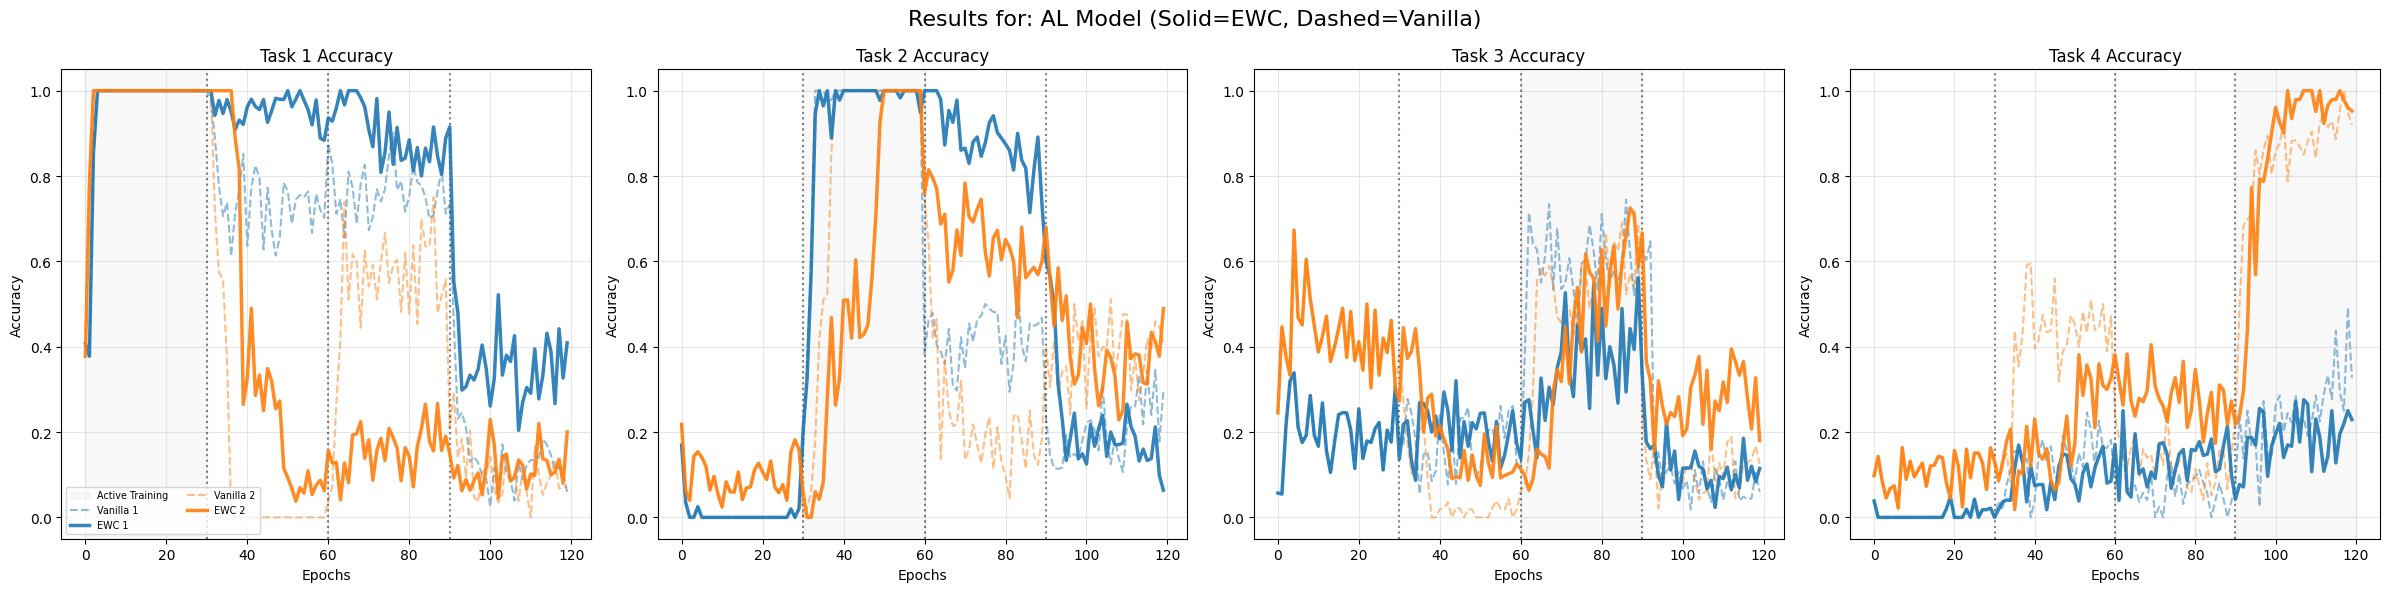


>>> STARTING BATCH FOR: Fully Model
>>> Seed set to: 1
   Running Vanilla 1/2...

>>> STARTING EXPERIMENT | EWC: OFF <<<
--- Phase 1: DelayedResponse (pro) | LR: 0.001 ---
   Ep 05 | Loss: 7.9890 | T1 Acc: 0.77 | T2 Acc: 0.17
   Ep 10 | Loss: 0.9593 | T1 Acc: 1.00 | T2 Acc: 0.18
   Ep 15 | Loss: 0.7568 | T1 Acc: 1.00 | T2 Acc: 0.12
   Ep 20 | Loss: 0.4652 | T1 Acc: 1.00 | T2 Acc: 0.10
   Ep 25 | Loss: 0.2019 | T1 Acc: 1.00 | T2 Acc: 0.10
   Ep 30 | Loss: 0.1309 | T1 Acc: 1.00 | T2 Acc: 0.12

[Config] Reducing Learning Rate: 0.001 -> 0.0001
--- Phase 2: DelayedResponse (anti) | LR: 0.0001 ---
   Ep 05 | Loss: 0.6390 | T1 Acc: 1.00 | T2 Acc: 0.98
   Ep 10 | Loss: 0.8314 | T1 Acc: 1.00 | T2 Acc: 1.00
   Ep 15 | Loss: 0.4910 | T1 Acc: 1.00 | T2 Acc: 1.00
   Ep 20 | Loss: 0.5949 | T1 Acc: 1.00 | T2 Acc: 1.00
   Ep 25 | Loss: 0.6951 | T1 Acc: 1.00 | T2 Acc: 1.00
   Ep 30 | Loss: 0.4163 | T1 Acc: 1.00 | T2 Acc: 1.00

[Config] Reducing Learning Rate: 0.0001 -> 0.0001
--- Phase 3: ReactionTime

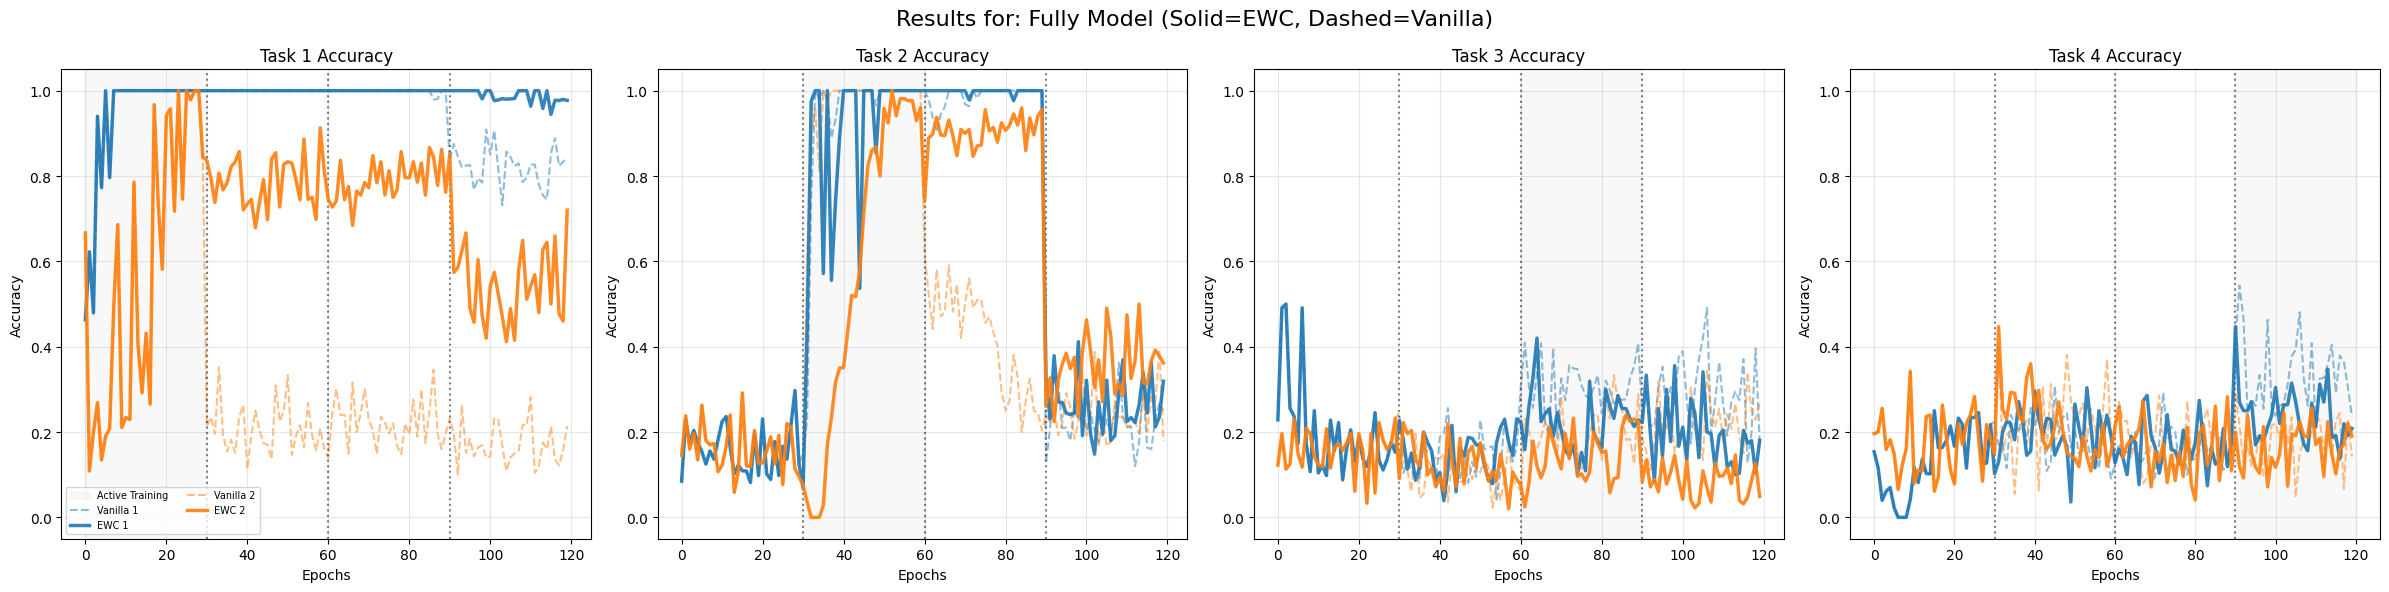

In [ ]:
# 1. Define your model configurations
# Ensure get_model_al and get_model_fully are defined before running this
model_configs = {
    "AL Model": get_model_al,
    "Fully Model": get_model_fully
}

tasks = [DelayedResponse(params, mode='pro'), 
         DelayedResponse(params, mode='anti'),
         ReactionTime(params, mode='pro'),
         ReactionTime(params, mode='anti')]

num_repeats = 2
epochs_per_task = 30  # Ensure this is defined
ewc_lambda = 1e6      # Defined here for consistency
num_tasks = len(tasks)  # Ensure this is defined based on your tasks

# 2. Loop through each model type
for model_name, model_init_fn in model_configs.items():
    print(f"\n{'='*40}")
    print(f">>> STARTING BATCH FOR: {model_name}")
    print(f"{'='*40}")
    
    # Store results specifically for this model type
    results = {}
    
    # --- Run Experiments ---
    for i in range(1, num_repeats + 1):
        # Run Vanilla
        set_seed(i)  # Different seed for each run
        print(f"   Running Vanilla {i}/{num_repeats}...")
        results[f'Vanilla {i}'] = train_experiment(
            model_init_fn, tasks, device, 
            ewc_lambda=None, 
            epochs_per_task=epochs_per_task
        )

        set_seed(i)
        # Run EWC
        print(f"   Running EWC {i}/{num_repeats}...")
        results[f'EWC {i}'] = train_experiment(
            model_init_fn, tasks, device, 
            ewc_lambda=ewc_lambda, 
            epochs_per_task=epochs_per_task
        )

    # --- Visualization for this model type ---
    plot_multitask_results(results, model_name, num_tasks=num_tasks)



In [19]:
model_configs = {
    "AL Model": get_model_al,
    "Fully Model": get_model_fully
}

tasks = [DelayedResponse(params, mode='pro'), 
         ReactionTime(params, mode='pro'),]

num_repeats = 2
epochs_per_task = 30  # Ensure this is defined
ewc_lambda = 1e6      # Defined here for consistency
num_tasks = len(tasks)  # Ensure this is defined based on your tasks

# 2. Loop through each model type
for model_name, model_init_fn in model_configs.items():
    print(f"\n{'='*40}")
    print(f">>> STARTING BATCH FOR: {model_name}")
    print(f"{'='*40}")
    
    # Store results specifically for this model type
    results = {}
    
    # --- Run Experiments ---
    for i in range(1, num_repeats + 1):
        # Run Vanilla
        set_seed(i)  # Different seed for each run
        print(f"   Running Vanilla {i}/{num_repeats}...")
        results[f'Vanilla {i}'] = train_experiment(
            model_init_fn, tasks, device, 
            ewc_lambda=None, 
            epochs_per_task=epochs_per_task
        )

        set_seed(i)
        # Run EWC
        print(f"   Running EWC {i}/{num_repeats}...")
        results[f'EWC {i}'] = train_experiment(
            model_init_fn, tasks, device, 
            ewc_lambda=ewc_lambda, 
            epochs_per_task=epochs_per_task
        )

    # --- Visualization for this model type ---
    plot_multitask_results(results, model_name, num_tasks=num_tasks)


>>> STARTING BATCH FOR: AL Model
>>> Seed set to: 1
   Running Vanilla 1/2...

>>> STARTING EXPERIMENT | EWC: OFF <<<
--- Phase 1: DelayedResponse (pro) | LR: 0.001 ---


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x11 and 13x100)

## Try it with bitcode snapshots

In [ ]:
import torch
import numpy as np

class BitcodeMonitor:
    def __init__(self, model, device, test_loaders_dict, L):
        """
        Args:
            model: The PyTorch ALRNN model.
            device: torch.device.
            test_loaders_dict: Dict {task_id: DataLoader} containing test data for all tasks.
            L: Integer, number of units to analyze (the ReLU/PWL units).
        """
        self.model = model
        self.device = device
        self.test_loaders = test_loaders_dict
        self.L = L
        # Stores distributions: {phase_idx: {task_id: distribution_dict}}
        self.history = {} 

    def on_phase_end(self, phase_idx, task_name):
        """Called at the end of each training phase to record bitcodes."""
        print(f"  [BitcodeAnalysis] Computing bitcodes after Phase {phase_idx}...")
        phase_results = {}
        
        # Analyze ALL tasks to see how representations evolve (checking for drift/forgetting)
        for task_id, loader in self.test_loaders.items():
            latents = self._extract_latents(loader)
            # Use the function you defined previously
            dist = bitcode_distribution(latents, self.L)
            phase_results[task_id] = dist
            
        self.history[phase_idx] = phase_results

    def _extract_latents(self, loader):
        """Helper to run inference and collect hidden states."""
        self.model.eval()
        latents_list = []
        with torch.no_grad():
            for batch in loader:
                # Unpack batch (handles variable return lengths if needed)
                inputs = batch[0].to(self.device)
                
                # --- CRITICAL ADAPTATION ---
                # We assume your model has a way to return hidden states.
                # If your forward() doesn't support this, you might need a separate 
                # method like `model.extract_hidden(inputs)`
                if hasattr(self.model, 'extract_hidden'):
                     hidden = self.model.extract_hidden(inputs)
                else:
                    # Fallback: Assume forward returns (output, hidden) if a flag is passed
                    # OR simply returns it by default. Adjust as needed.
                    try:
                        _, hidden = self.model(inputs, return_hidden=True)
                    except TypeError:
                        # Fallback for models that always return tuples
                        _, hidden = self.model(inputs)

                latents_list.append(hidden.cpu().numpy())
        
        # Concatenate to shape: (Total_Samples, Time_Steps, Hidden_Dim)
        return np.concatenate(latents_list, axis=0)

    def plot_final_heatmap(self):
        """Plots the bitcode heatmap for the final state of the model."""
        if not self.history:
            print("No history to plot.")
            return

        last_phase_idx = max(self.history.keys())
        final_dists = self.history[last_phase_idx]
        
        # Use your defined alignment function
        aligned_matrix, labels = align_bitcode_distributions(final_dists)
        task_names = [f"Task {t}" for t in final_dists.keys()]
        
        # Use your defined plotting function
        plot_bitcode_distributions(
            latent_states=None, 
            model=None, 
            task_names=task_names, 
            aligned_matrix=aligned_matrix, 
            bitcode_labels=labels
        )